In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from xgboost import XGBClassifier

In [3]:
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

df_final = pd.concat([df_train, df_test], ignore_index=True)

In [4]:
# define three-year mortalitty status
df_train.loc[:,'MORTSTAT3Y'] = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 1, 0)
df_test.loc[:,'MORTSTAT3Y'] = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 1, 0)

In [5]:
# select features and target
X_train = df_train.drop(columns=['MORTSTAT3Y', 'TIMETOEVENT', 'MORTSTAT'])
y_train = df_train['MORTSTAT3Y']

X_test = df_test.drop(columns=['MORTSTAT3Y', 'TIMETOEVENT', 'MORTSTAT'])
y_test = df_test['MORTSTAT3Y']

In [6]:
xgbc = XGBClassifier(objective='binary:logistic', random_state=42,
                     n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.5, colsample_bytree=0.8)
xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [7]:
proba_train = xgbc.predict_proba(X_train)[:, 1]
proba_test = xgbc.predict_proba(X_test)[:, 1]
proba_final = np.concatenate([proba_train, proba_test])

In [8]:
# df_1990

In [9]:
# Load the saved x_vals and y_vals from the file
data = np.load('x_y_vals.npz')

# Extract x_vals and y_vals
x_vals = data['x_vals']
y_vals = data['y_vals']

# Define the interpolation function T
def T(x):
    return np.interp(x, x_vals, y_vals)

# Example usage: Interpolate for some new x values
new_x_vals = np.linspace(np.min(x_vals), np.max(x_vals), 100)
new_y_vals = T(new_x_vals)

df_train_1990 = df_train.copy()
df_test_1990 = df_test.copy()

df_train_1990['BMICALC'] = T(df_train['BMICALC'])
df_test_1990['BMICALC'] = T(df_test['BMICALC'])

In [10]:
train_num = len(df_train_1990)
test_num = len(df_test_1990)

df_final_1990 = pd.concat([df_train_1990, df_test_1990], ignore_index=False)

In [11]:
# get ppl that should be adjsuted 
with open('selected_people_hyper.pkl', 'rb') as f:
    selected_people_hyper = pickle.load(f)
with open('selected_people_diab.pkl', 'rb') as f:
    selected_people_diab = pickle.load(f)

In [12]:
# make ppl healthy
df_final_1990.loc[df_final_1990.index.isin(selected_people_diab), 'DIABETICEV'] = 1
df_final_1990.loc[df_final_1990.index.isin(selected_people_hyper), 'HYPERTENEV'] = 1

In [13]:
df_train_1990 = df_final_1990.head(train_num)
df_test_1990 = df_final_1990.tail(test_num)

In [14]:
# define three-year mortalitty status
df_train_1990 = df_train_1990.copy()
df_train_1990.loc[:,'MORTSTAT3Y'] = np.where((df_train_1990["MORTSTAT"] == 1) & (df_train_1990["TIMETOEVENT"] <= 3), 1, 0)
df_test_1990 = df_test_1990.copy()
df_test_1990.loc[:,'MORTSTAT3Y'] = np.where((df_test_1990["MORTSTAT"] == 1) & (df_test_1990["TIMETOEVENT"] <= 3), 1, 0)

In [15]:
# select features and target
X_train_1990 = df_train_1990.drop(columns=['MORTSTAT3Y', 'TIMETOEVENT', 'MORTSTAT'])
y_train_1990 = df_train_1990['MORTSTAT3Y']

X_test_1990 = df_test_1990.drop(columns=['MORTSTAT3Y', 'TIMETOEVENT', 'MORTSTAT'])
y_test_1990 = df_test_1990['MORTSTAT3Y']

In [16]:
# get adjusted probabilites

In [17]:
proba_train_1990 = xgbc.predict_proba(X_train_1990)[:, 1]
proba_test_1990 = xgbc.predict_proba(X_test_1990)[:, 1]
proba_final_1990 = np.concatenate([proba_train_1990, proba_test_1990])

In [18]:
# --- MSD ---
print(f"final dataset {np.mean((proba_final_1990 - proba_final) ** 2):.6f}")
print(f"training dataset {np.mean((proba_train_1990 - proba_train) ** 2):.6f}")
print(f"test dataset {np.mean((proba_test_1990 - proba_test) ** 2):.6f}")

final dataset 0.000066
training dataset 0.000068
test dataset 0.000057


In [19]:
# --- MAD ---
print(f"final dataset {np.mean(np.abs(proba_final_1990 - proba_final)):.5f}")
print(f"training dataset {np.mean(np.abs(proba_train_1990 - proba_train)):.5f}")
print(f"test dataset {np.mean(np.abs(proba_test_1990 - proba_test)):.5f}")

final dataset 0.00251
training dataset 0.00259
test dataset 0.00220


In [20]:
# --- SGR ---
indicator_final = np.array([1 if p > p_1990 else 0 for p, p_1990 in zip(proba_final_1990, proba_final)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p > p_1990 else 0 for p, p_1990 in zip(proba_train_1990, proba_train)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p > p_1990 else 0 for p, p_1990 in zip(proba_test_1990, proba_test)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.5142649903288201
train dataset 0.5051499032882012
test dataset 0.5507253384912959


In [21]:
# --- SLR ---
indicator_final = np.array([1 if p < p_1990 else 0 for p, p_1990 in zip(proba_final_1990, proba_final)])
print(f"final dataset {np.mean(indicator_final)}")
indicator_train = np.array([1 if p < p_1990 else 0 for p, p_1990 in zip(proba_train_1990, proba_train)])
print(f"train dataset {np.mean(indicator_train)}")
indicator_test = np.array([1 if p < p_1990 else 0 for p, p_1990 in zip(proba_test_1990, proba_test)])
print(f"test dataset {np.mean(indicator_test)}")

final dataset 0.3552514506769826
train dataset 0.3684840425531915
test dataset 0.302321083172147


In [22]:
# get plots

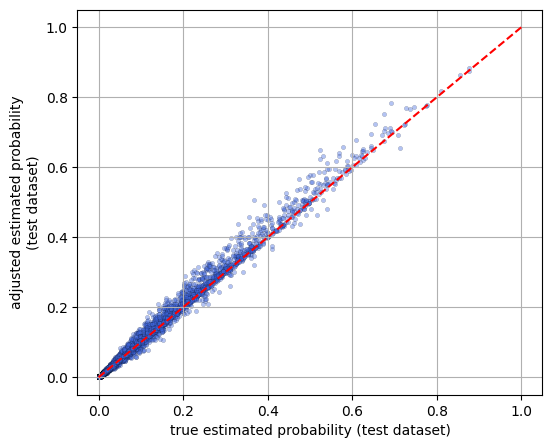

In [23]:
plt.figure(figsize=(6,5))
plt.scatter(proba_test,proba_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.4)   
plt.xlabel(f'true estimated probability (test dataset)')
plt.ylabel(f'adjusted estimated probability\n(test dataset)')
plt.grid(True)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.savefig('multi_XGBC_diagnoal_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

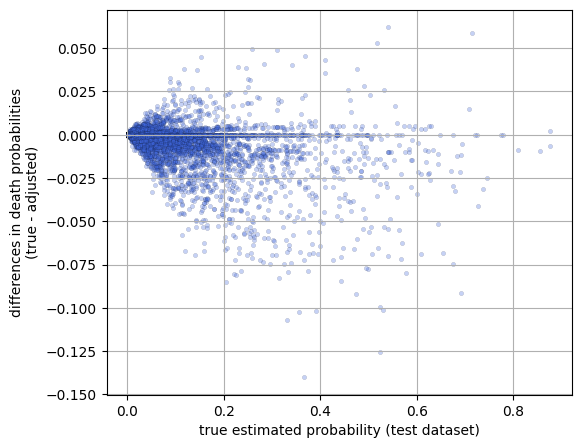

In [24]:
plt.figure(figsize=(6,5))
plt.scatter(proba_test, proba_test - proba_test_1990, color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('true estimated probability (test dataset)')
plt.ylabel(f'differences in death probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('multi_XGBC_prob_differences_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

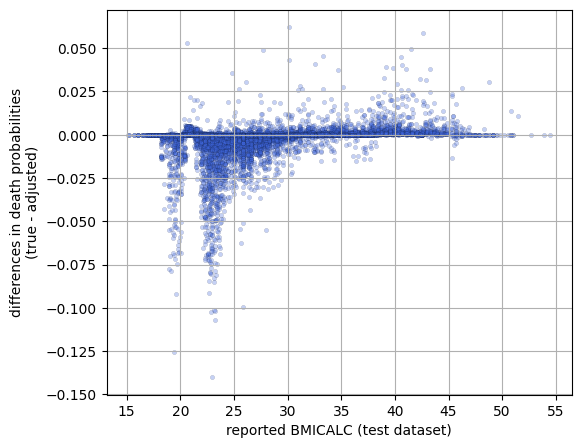

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(X_test['BMICALC'], (proba_test- proba_test_1990), color='royalblue', edgecolor='black', linewidths=0.2, s=10, alpha=0.3)  
plt.xlabel('reported BMICALC (test dataset)')
plt.ylabel(f'differences in death probabilities\n(true - adjusted)')
plt.grid(True)
plt.savefig('multi_XGBC_bmi_test.png', format='png', dpi=300, bbox_inches='tight')
plt.show()